# 🚢 Titanic - Machine Learning from Disaster

## Phase 1: Data Understanding

### Objective

The objective of this notebook is to develop a thorough understanding of the Titanic dataset before performing any data cleaning, exploratory data analysis, feature engineering, or machine learning.

In this phase, we will:

* Load the training, test, and sample submission datasets.
* Understand the role of each dataset.
* Inspect the dimensions and structure of the data.
* Understand the meaning of every feature.
* Identify numerical and categorical variables.
* Inspect data types.
* Identify missing values.
* Examine unique values and cardinality.
* Review descriptive statistics.
* Analyze the distribution of the target variable (`Survived`).
* Establish a simple baseline accuracy.
* Identify potential areas that require further investigation.

## 1. Import Libraries

We begin by importing the Python libraries required for data inspection and basic visualization.

* **Pandas** will be used for loading, inspecting, and manipulating tabular data.
* **NumPy** provides numerical computing utilities.
* **Matplotlib** and **Seaborn** will be used for basic visualizations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Datasets

The Titanic competition provides three important files:

* `train.csv` — Contains passenger information along with the target variable, `Survived`. This dataset will be used to train and validate our machine learning models.
* `test.csv` — Contains passenger information without the `Survived` column. Our final model will generate predictions for these passengers.
* `gender_submission.csv` — A sample submission file provided by Kaggle. It demonstrates the exact format required when submitting predictions.

The original files are stored inside the `data/raw/` directory.


In [31]:
train_path = "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/raw/train.csv"
test_path = "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/raw/test.csv"
sample_submission_path = "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/raw/gender_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 3. Initial Dataset Inspection

Before performing any detailed analysis, we will inspect the first few rows of each dataset.

This allows us to verify that the files were loaded correctly and provides an initial understanding of how the data is structured.

In [5]:
print("Training Dataset:")
display(train.head())

Training Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Test Dataset:")
display(test.head())

Test Dataset:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
print("Sample Submission:")
display(sample_submission.head())

Sample Submission:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 4. Dataset Dimensions

Next, we inspect the number of rows and columns in each dataset.

The dataset shape is represented as:

`(number of rows, number of columns)`

Understanding the dimensions helps us confirm how many passenger records and features are available for training and prediction.


In [8]:
print(f"Training dataset : {train.shape[0]} rows × {train.shape[1]} columns")
print(f"Test dataset     : {test.shape[0]} rows × {test.shape[1]} columns")
print(f"Sample submission: {sample_submission.shape[0]} rows × {sample_submission.shape[1]} columns")

Training dataset : 891 rows × 12 columns
Test dataset     : 418 rows × 11 columns
Sample submission: 418 rows × 2 columns


### Observation

The training dataset contains **891 passenger records and 12 columns**, while the test dataset contains **418 passenger records and 11 columns**.

The difference of one column is due to the target variable, `Survived`, which is available only in the training dataset.

The sample submission contains **418 rows**, matching the number of passengers in the test dataset. This confirms that one survival prediction must eventually be generated for every passenger in `test.csv`.


## 5. Compare Training and Test Columns

The training and test datasets should contain the same predictor variables, with the exception of the target variable `Survived`.

We will compare their column names to confirm this.


In [9]:
print("Training columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Training columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Test columns:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [10]:
train_only_columns = set(train.columns) - set(test.columns)
test_only_columns = set(test.columns) - set(train.columns)

print("Columns only in training data:", train_only_columns)
print("Columns only in test data:", test_only_columns)

Columns only in training data: {'Survived'}
Columns only in test data: set()


## 6. Inspect Data Types

Understanding data types is important because different types of variables require different preprocessing strategies.

At this stage, we will only inspect the current data types without modifying them.


In [12]:
print("Training Dataset Information:\n")
train.info()

Training Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
print("Test Dataset Information:\n")
test.info()

Test Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [14]:
dtype_summary = pd.DataFrame({
    "Column": train.columns,
    "Data Type": train.dtypes.astype(str).values,
    "Non-Null Count": train.notnull().sum().values,
    "Null Count": train.isnull().sum().values
})

dtype_summary

,Column,Data Type,Non-Null Count,Null Count
0,PassengerId,int64,891,0
1,Survived,int64,891,0
2,Pclass,int64,891,0
3,Name,object,891,0
4,Sex,object,891,0
5,Age,float64,714,177
6,SibSp,int64,891,0
7,Parch,int64,891,0
8,Ticket,object,891,0
9,Fare,float64,891,0


## 7. Missing Value Overview

Missing data can significantly affect both exploratory analysis and machine learning models.

We will calculate both:

* The total number of missing values.
* The percentage of missing values.

In [15]:
def missing_value_summary(df):
    summary = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing Percentage": (df.isnull().mean() * 100).round(2)
    })
    
    return summary[summary["Missing Count"] > 0].sort_values(
        by="Missing Percentage",
        ascending=False
    )

In [16]:
print("Missing Values - Training Dataset:")
display(missing_value_summary(train))

Missing Values - Training Dataset:


,Missing Count,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [17]:
print("Missing Values - Test Dataset:")
display(missing_value_summary(test))

Missing Values - Test Dataset:


,Missing Count,Missing Percentage
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


## 8. Unique Values and Cardinality

Cardinality refers to the number of unique values present in a feature.

Understanding cardinality helps us distinguish between:

* Identifier-like variables.
* Low-cardinality categorical variables.
* High-cardinality categorical variables.
* Continuous or discrete numerical variables.

In [18]:
cardinality_summary = pd.DataFrame({
    "Column": train.columns,
    "Unique Values": train.nunique().values,
    "Missing Values": train.isnull().sum().values
})

cardinality_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Column,Unique Values,Missing Values
0,PassengerId,891,0
3,Name,891,0
8,Ticket,681,0
9,Fare,248,0
10,Cabin,147,687
5,Age,88,177
6,SibSp,7,0
7,Parch,7,0
11,Embarked,3,2
2,Pclass,3,0


## 9. Inspect Categorical Feature Values

We will inspect the frequency of values in the main low-cardinality categorical features.

This helps identify the categories present in the dataset and may reveal missing values or unexpected labels.


In [19]:
categorical_columns = ["Sex", "Embarked", "Pclass"]

for column in categorical_columns:
    print(f"\nValue Counts for '{column}':")
    print(train[column].value_counts(dropna=False))


Value Counts for 'Sex':
Sex
male      577
female    314
Name: count, dtype: int64

Value Counts for 'Embarked':
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Value Counts for 'Pclass':
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


## 10. Descriptive Statistics for Numerical Features

Descriptive statistics provide a summary of the central tendency, spread, and range of numerical variables.

In [20]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [21]:
train.describe(include=["object"]).T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,1601,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


## 11. Duplicate Row Check

Duplicate records can distort analysis and potentially bias machine learning models.

We will check whether the datasets contain any completely duplicated rows.

This check only identifies exact row-level duplicates. Repeated values in columns such as `Ticket` or `Cabin` are not necessarily duplicates because multiple passengers may legitimately share them.


In [22]:
print(f"Duplicate rows in training data: {train.duplicated().sum()}")
print(f"Duplicate rows in test data: {test.duplicated().sum()}")

Duplicate rows in training data: 0
Duplicate rows in test data: 0


In [23]:
print(
    "Training PassengerId unique:",
    train["PassengerId"].is_unique
)

print(
    "Test PassengerId unique:",
    test["PassengerId"].is_unique
)

Training PassengerId unique: True
Test PassengerId unique: True


## 12. Target Variable Analysis

The target variable for this competition is `Survived`.

A majority-class baseline predicts the most common class for every passenger. Any useful machine learning model should perform meaningfully better than this simple strategy.


In [24]:
survival_counts = train["Survived"].value_counts().sort_index()
survival_percentages = (
    train["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": survival_counts,
    "Percentage": survival_percentages
})

target_summary.index = ["Did Not Survive (0)", "Survived (1)"]

target_summary

,Count,Percentage
Did Not Survive (0),549,61.62
Survived (1),342,38.38


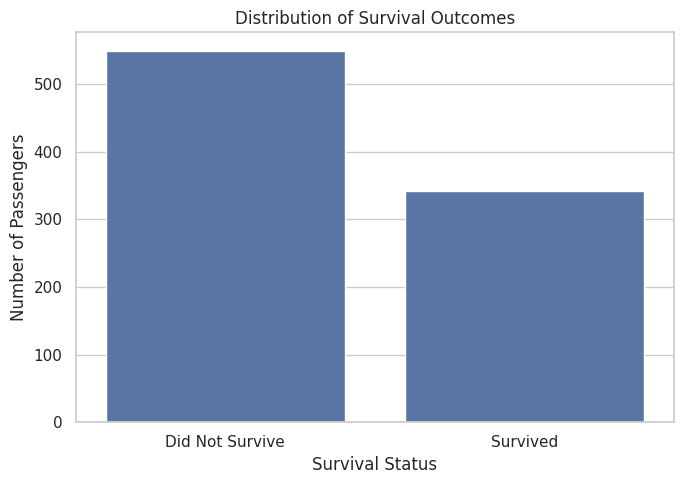

In [25]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=train,
    x="Survived"
)

plt.title("Distribution of Survival Outcomes")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])

plt.tight_layout()
plt.show()

In [26]:
majority_class = train["Survived"].mode()[0]

baseline_accuracy = (
    train["Survived"].value_counts(normalize=True).max()
)

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Majority class: 0
Baseline accuracy: 61.62%


## 13. Basic Train-Test Consistency Check

The training and test datasets should represent similar populations because the model will learn patterns from the training data and apply them to the test data.

In [27]:
comparison_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

comparison = pd.DataFrame({
    "Train Mean": train[comparison_columns].mean(),
    "Test Mean": test[comparison_columns].mean(),
    "Train Median": train[comparison_columns].median(),
    "Test Median": test[comparison_columns].median()
})

comparison.round(2)

,Train Mean,Test Mean,Train Median,Test Median
Pclass,2.31,2.27,3.00,3.00
Age,29.70,30.27,28.00,27.00
SibSp,0.52,0.45,0.00,0.00
Parch,0.38,0.39,0.00,0.00
Fare,32.20,35.63,14.45,14.45


## 14. Phase 1 Summary

In this notebook, we performed an initial investigation of the raw Titanic competition data.

### What We Completed

* Loaded the training, test, and sample submission datasets.
* Inspected the first few records from each dataset.
* Examined dataset dimensions and column structure.
* Confirmed that `Survived` is the target variable available only in the training dataset.
* Reviewed the meaning of each feature using a data dictionary.
* Inspected data types and non-null counts.
* Identified features containing missing values.
* Examined feature cardinality and unique values.
* Reviewed descriptive statistics for numerical and categorical features.
* Checked for completely duplicated rows.
* Verified the uniqueness of passenger identifiers.
* Analyzed the distribution of the target variable.
* Established a majority-class baseline accuracy.
* Performed a basic comparison between training and test data.
